In [2]:

import datetime
import os
from pathlib import Path
from src.utils.ModelUtility import model_snapshot
import torch
from torch import optim
import torchvision
import torchvision.transforms as transforms

In [4]:
unique_subspaces = [torch.Tensor([1,0,1]), torch.Tensor([1,1,1])]
proba = [0.5, 0.5]
big_u = torch.zeros(3)

for i in range(len(unique_subspaces)):
    p = proba[i]
    s = torch.tensor(unique_subspaces[i]).to(dtype=torch.float64)
    big_u += p * s
big_u

/var/folders/zf/8fhgsy8n6nn65ngw4_4l9mp80000gn/T/ipykernel_59583/3501327764.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(unique_subspaces[i]).to(dtype=torch.float64)


IndexError: list index out of range

In [2]:

import torch.nn as nn

class CIFAR10Upscaler(nn.Module):
    def __init__(self):
        super(CIFAR10Upscaler, self).__init__()
        self.conv1 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)  # Keep 3 channels
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  # 32x32 -> 64x64
        self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  # 64x64 -> 128x128
        self.upsample3 = nn.Upsample(scale_factor=1.75, mode='bilinear', align_corners=True)  # 128x128 -> 224x224
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.upsample1(x)
        x = self.relu(self.conv2(x))
        x = self.upsample2(x)
        x = self.relu(self.conv3(x))
        x = self.upsample3(x)
        return x


In [3]:
import torch
import torch.nn as nn

class CIFAR10Downscaler(nn.Module):
    def __init__(self):
        super(CIFAR10Downscaler, self).__init__()
        self.conv1 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)  # Keep 3 channels
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(3, 3, kernel_size=3, stride=1, padding=1)

        # Pooling layers to downscale dimensions
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  # 224x224 -> 112x112
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  # 112x112 -> 56x56
        self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)  # 56x56 -> 28x28
        self.upsample_final = nn.Upsample(size=(32, 32), mode='bilinear', align_corners=True)  # 28x28 -> 32x32

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)  # First downscale
        x = self.relu(self.conv2(x))
        x = self.pool2(x)  # Second downscale
        x = self.relu(self.conv3(x))
        x = self.pool3(x)  # Third downscale
        x = self.upsample_final(x)  # Resize to 32x32

        return x


In [4]:
from src.models.autoencoder.resnet.RestNetAutoEncoder import ResNet18AutoEncoder


class CombinedModel(nn.Module):
    def __init__(self):
        super(CombinedModel, self).__init__()
        self.upscaler = CIFAR10Upscaler()
        self.pretrained_model = ResNet18AutoEncoder()

        for param in self.pretrained_model.parameters():
            param.requires_grad = False

        self.downscaler = CIFAR10Downscaler()

    def forward(self, x):
        x = self.upscaler(x)
        x = self.pretrained_model(x)
        x = self.downscaler(x)
        return x

In [5]:
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
cats_dataset = [(img, label) for (img, label) in dataset if label == 3]
cats_dataloader = torch.utils.data.DataLoader(cats_dataset, batch_size=32, shuffle=True)

Files already downloaded and verified


In [6]:


# Set device to GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'mps:0' if torch.backends.mps.is_available() else 'cpu')

# Move model to device
combined_model = CombinedModel().to(device)

# Initialize optimizer for parameters requiring gradients
optimizer = optim.Adam([param for param in combined_model.parameters() if param.requires_grad], lr=0.001)
criterion = nn.MSELoss()
losses = []
batch_number = cats_dataloader.__len__()
n_epochs = 100
# Training loop
for epoch in range(n_epochs):  # Few epochs to adapt the preprocessor layer

    print(f'\rEpoch {epoch} of {n_epochs}')
    autoencoder_loss = 0

    for images, _ in cats_dataloader:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = combined_model(images)

        batch_loss = criterion(outputs, images)

        autoencoder_loss += float(batch_loss.to(
                    'cpu').detach().numpy())/batch_number

        batch_loss.backward()
        optimizer.step()

    print(f"Average loss in the epoch: {autoencoder_loss}")
    losses.append(autoencoder_loss)

Epoch 0 of 100
Average loss in the epoch: 0.07656291708540004
Epoch 1 of 100
Average loss in the epoch: 0.01165962743626279
Epoch 2 of 100
Average loss in the epoch: 0.009223613570663767
Epoch 3 of 100
Average loss in the epoch: 0.007367667137010462
Epoch 4 of 100
Average loss in the epoch: 0.006479106143496603
Epoch 5 of 100
Average loss in the epoch: 0.0064962202605975275
Epoch 6 of 100
Average loss in the epoch: 0.00591100011448002
Epoch 7 of 100
Average loss in the epoch: 0.005929823795772475
Epoch 8 of 100
Average loss in the epoch: 0.005733805671512228
Epoch 9 of 100
Average loss in the epoch: 0.005466816252821193
Epoch 10 of 100
Average loss in the epoch: 0.005403133213021763
Epoch 11 of 100
Average loss in the epoch: 0.005515411807591937
Epoch 12 of 100
Average loss in the epoch: 0.0053218103527049926
Epoch 13 of 100
Average loss in the epoch: 0.005147089625584186
Epoch 14 of 100
Average loss in the epoch: 0.005118503818098621
Epoch 15 of 100
Average loss in the epoch: 0.005204

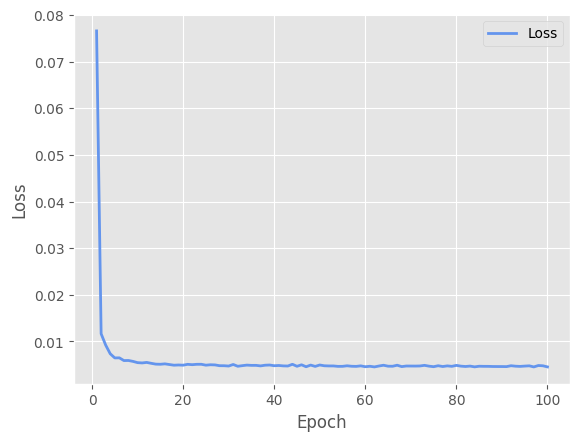

In [7]:
model_snapshot(losses, combined_model, "resnet18_scaled_autoencoder", path_to_directory=Path(os.getcwd()).parent / "experiments" / "autoencoder" / f"resnet18_{datetime.datetime.now()}_scaled_autoencoder", run_number=n_epochs)